# Capitolo 4 — Dati reali: normalizzazione, overfitting, metriche
Wisconsin Breast Cancer: 569 casi, 30 caratteristiche.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import numpy as np
import matplotlib.pyplot as plt

import torch, pandas as pd
from torch import nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
fissa_seme(42)

## 4.1 Il dataset

In [2]:
dati = load_breast_cancer(as_frame=True)
df = dati.frame
print(df.shape)
print(df["target"].value_counts())
df.describe().T[["mean", "min", "max"]].head(8)

(569, 31)
target
1    357
0    212
Name: count, dtype: int64


,mean,min,max
mean radius,14.127292,6.98100,28.1100
mean texture,19.289649,9.71000,39.2800
mean perimeter,91.969033,43.79000,188.5000
mean area,654.889104,143.50000,2501.0000
mean smoothness,0.096360,0.05263,0.1634
mean compactness,0.104341,0.01938,0.3454
mean concavity,0.088799,0.00000,0.4268
mean concave points,0.048919,0.00000,0.2012


In [3]:
X = df.drop(columns="target").values.astype(np.float32)
y = 1 - df["target"].values.astype(np.float32)     # ora 1 = maligno (classe positiva)

## 4.2 Tre insiemi

In [4]:
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_va, X_te, y_va, y_te   = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)
print(len(X_tr), len(X_va), len(X_te), " frazione maligni nel training:", round(y_tr.mean(), 3))

398 85 86  frazione maligni nel training: 0.372


## 4.3 Normalizzazione (statistiche dal solo training)

In [5]:
scaler = StandardScaler().fit(X_tr)
Xn_tr = scaler.transform(X_tr).astype(np.float32)
Xn_va = scaler.transform(X_va).astype(np.float32)
Xn_te = scaler.transform(X_te).astype(np.float32)
print("prima colonna dopo la normalizzazione: media", Xn_tr[:, 0].mean().round(4), "dev", Xn_tr[:, 0].std().round(4))

prima colonna dopo la normalizzazione: media 0.0 dev 1.0


## 4.4 Modello e ciclo con validazione ed early stopping

In [6]:
def fai_modello(nascosti=256, dropout=0.0):
    return nn.Sequential(
        nn.Linear(30, nascosti), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(nascosti, nascosti), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(nascosti, 1),
    )

perdita_fn = nn.BCEWithLogitsLoss()

def addestra(modello, Xtr, ytr, Xva, yva, epoche=300, lr=1e-3, weight_decay=0.0, pazienza=None):
    opt = torch.optim.Adam(modello.parameters(), lr=lr, weight_decay=weight_decay)
    Xtr, ytr, Xva, yva = map(torch.from_numpy, (Xtr, ytr, Xva, yva))
    storia = {"train": [], "val": []}
    migliore = {"perdita": float("inf"), "pesi": None, "epoca": 0}
    attesa = 0
    for epoca in range(epoche):
        modello.train()
        opt.zero_grad()
        perdita = perdita_fn(modello(Xtr).squeeze(1), ytr)
        perdita.backward()
        opt.step()
        modello.eval()
        with torch.no_grad():
            perdita_val = perdita_fn(modello(Xva).squeeze(1), yva).item()
        storia["train"].append(perdita.item()); storia["val"].append(perdita_val)
        if perdita_val < migliore["perdita"]:
            migliore = {"perdita": perdita_val, "epoca": epoca,
                        "pesi": {k: v.clone() for k, v in modello.state_dict().items()}}
            attesa = 0
        else:
            attesa += 1
            if pazienza is not None and attesa >= pazienza:
                break
    return storia, migliore

def stampa(storia, epoche=(1, 25, 50, 100, 200, 300)):
    for e in epoche:
        if e <= len(storia["train"]):
            print(f"Epoca {e:3d}: train {storia['train'][e-1]:.4f}   val {storia['val'][e-1]:.4f}")

def grafico(storia, titolo=""):
    plt.plot(storia["train"], label="train"); plt.plot(storia["val"], label="val")
    plt.xlabel("Epoca"); plt.ylabel("Perdita"); plt.legend(); plt.grid(True); plt.title(titolo); plt.show()

def metriche(modello, X, y, soglia=0.5):
    modello.eval()
    with torch.no_grad():
        prob = torch.sigmoid(modello(torch.from_numpy(X)).squeeze(1)).numpy()
    pred = (prob > soglia).astype(int)
    return {"accuratezza": accuracy_score(y, pred), "precisione": precision_score(y, pred),
            "recall": recall_score(y, pred), "matrice": confusion_matrix(y, pred)}

### Senza normalizzazione

In [7]:
fissa_seme(42)
m = fai_modello()
storia, _ = addestra(m, X_tr, y_tr, X_va, y_va)
stampa(storia); print(metriche(m, X_te, y_te))

Epoca   1: train 9.8175   val 18.2850
Epoca  25: train 0.6207   val 1.5258
Epoca  50: train 0.2469   val 0.2809
Epoca 100: train 0.1782   val 0.2385
Epoca 200: train 0.1365   val 0.1937
Epoca 300: train 0.1115   val 0.2082
{'accuratezza': 0.9186046511627907, 'precisione': 1.0, 'recall': 0.78125, 'matrice': array([[54,  0],
       [ 7, 25]])}


### Con normalizzazione: l'overfitting visto

Epoca   1: train 0.6888   val 0.6126
Epoca  25: train 0.0723   val 0.0729
Epoca  50: train 0.0347   val 0.1248
Epoca 100: train 0.0058   val 0.2204
Epoca 200: train 0.0007   val 0.3192
Epoca 300: train 0.0002   val 0.3662
minimo val 0.0723 epoca 27


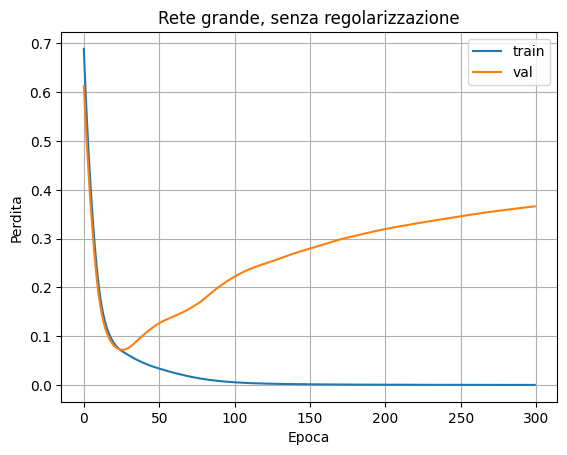

{'accuratezza': 0.9767441860465116, 'precisione': 1.0, 'recall': 0.9375, 'matrice': array([[54,  0],
       [ 2, 30]])}


In [8]:
fissa_seme(42)
m = fai_modello()
storia, migliore = addestra(m, Xn_tr, y_tr, Xn_va, y_va)
stampa(storia); print("minimo val", round(migliore["perdita"], 4), "epoca", migliore["epoca"] + 1)
grafico(storia, "Rete grande, senza regolarizzazione")
print(metriche(m, Xn_te, y_te))

## 4.5 Rimedi: dropout + weight decay, poi early stopping

Epoca   1: train 0.6906   val 0.6165
Epoca  25: train 0.0879   val 0.0738
Epoca  50: train 0.0538   val 0.0723
Epoca 100: train 0.0278   val 0.1091
Epoca 200: train 0.0115   val 0.1670
Epoca 300: train 0.0079   val 0.2403
minimo val 0.0683 epoca 31


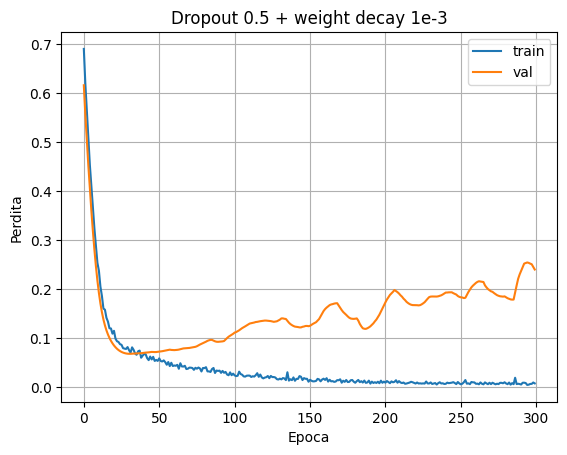

In [9]:
fissa_seme(42)
m = fai_modello(dropout=0.5)
storia, migliore = addestra(m, Xn_tr, y_tr, Xn_va, y_va, weight_decay=1e-3)
stampa(storia); print("minimo val", round(migliore["perdita"], 4), "epoca", migliore["epoca"] + 1)
grafico(storia, "Dropout 0.5 + weight decay 1e-3")

In [10]:
fissa_seme(42)
modello = fai_modello(dropout=0.5)
storia, migliore = addestra(modello, Xn_tr, y_tr, Xn_va, y_va, weight_decay=1e-3, pazienza=30)
print("Fermato all'epoca", len(storia["train"]), "— migliore:", migliore["epoca"] + 1)
modello.load_state_dict(migliore["pesi"])

Fermato all'epoca 61 — migliore: 31


<All keys matched successfully>

## 4.6 Metriche — soglia scelta sul VALIDATION set, test guardato una volta

In [11]:
for soglia in (0.5, 0.4, 0.3, 0.2, 0.1):
    r = metriche(modello, Xn_va, y_va, soglia)
    print(f"val, soglia {soglia}: acc {r['accuratezza']:.3f}  prec {r['precisione']:.3f}  recall {r['recall']:.3f}")

val, soglia 0.5: acc 0.988  prec 1.000  recall 0.969
val, soglia 0.4: acc 0.988  prec 1.000  recall 0.969
val, soglia 0.3: acc 0.953  prec 0.912  recall 0.969
val, soglia 0.2: acc 0.953  prec 0.912  recall 0.969
val, soglia 0.1: acc 0.929  prec 0.861  recall 0.969


In [12]:
soglia_scelta = 0.5     # modificare in base ai risultati sul validation set qui sopra
r = metriche(modello, Xn_te, y_te, soglia_scelta)
print(r["matrice"])
print(f"TEST — accuratezza {r['accuratezza']:.3f}  precisione {r['precisione']:.3f}  recall {r['recall']:.3f}")

[[54  0]
 [ 1 31]]
TEST — accuratezza 0.988  precisione 1.000  recall 0.969


Per il capitolo 7: salvare i pesi e le statistiche dello scaler.

In [13]:
torch.save(modello.state_dict(), "tumori.pt")
np.savez("tumori_scaler.npz", media=scaler.mean_, dev=scaler.scale_)